<a href="https://colab.research.google.com/github/madayanthikaar17/intravenous-therapy/blob/main/REDNESS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, gc
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Lambda
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

In [ ]:
from google.colab import files
import zipfile
import os

# Step 1: Upload ZIP
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print("Uploaded:", zip_name)

# Step 2: Unzip to a dataset folder
dataset_path = "with_withoutredness"
os.makedirs(dataset_path, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(dataset_path)

print("Unzipped to:", dataset_path)

# Step 3: Check extracted files
print("Files:", os.listdir(dataset_path))

Saving withoutrednessnew (2).zip to withoutrednessnew (2).zip
Uploaded: withoutrednessnew (2).zip
Unzipped to: with_withoutredness
Files: ['withoutrednessnew']


In [ ]:
from google.colab import files
import zipfile
import os

# Step 1: Upload ZIP
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print("Uploaded:", zip_name)

# Step 2: Unzip to a dataset folder
dataset_path = "with_withoutredness"
os.makedirs(dataset_path, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(dataset_path)

print("Unzipped to:", dataset_path)

# Step 3: Check extracted files
print("Files:", os.listdir(dataset_path))

Saving withrednessnew.zip to withrednessnew.zip
Uploaded: withrednessnew.zip
Unzipped to: with_withoutredness
Files: ['withrednessnew', 'withoutrednessnew']


In [ ]:
import os
import numpy as np
import cv2
from tqdm import tqdm

IMG_SIZE = 224
DATASET_PATH = "/content/with_withoutredness"

X = []
y = []

classes = ["withoutredness", "withredness"]

for label, class_name in enumerate(classes):
    folder = os.path.join(DATASET_PATH, class_name)

    for img_name in tqdm(os.listdir(folder)):
        img_path = os.path.join(folder, img_name)

        if img_name.lower().endswith((".jpg", ".png", ".jpeg")):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            X.append(img)
            y.append(label)

X = np.array(X, dtype=np.uint8)
y = np.array(y, dtype=np.uint8)

print("X shape:", X.shape)
print("y shape:", y.shape)

np.save("/content/X_redness.npy", X)
np.save("/content/y_redness.npy", y)

print("✅ Saved as NPY successfully")

100%|██████████| 71/71 [00:00<00:00, 117.65it/s]

X shape: (182, 224, 224, 3)
y shape: (182,)
✅ Saved as NPY successfully


In [ ]:
import numpy as np
import os
import cv2
from tqdm import tqdm

X = np.load("/content/X_redness.npy")
y = np.load("/content/y_redness.npy")

print("Loaded:", X.shape)


Loaded: (182, 224, 224, 3)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Before Augmentation:")
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

Before Augmentation:
Train: (127, 224, 224, 3) (127,)
Val: (55, 224, 224, 3) (55,)


In [ ]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([

    # Flips
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),

    # Rotation
    tf.keras.layers.RandomRotation(0.1),

    # Zoom
    tf.keras.layers.RandomZoom(0.15),

    # Translation
    tf.keras.layers.RandomTranslation(0.1, 0.1),

    # Contrast / brightness
    tf.keras.layers.RandomContrast(0.15),

    # Slight blur approximation
    tf.keras.layers.AveragePooling2D(pool_size=2),
    tf.keras.layers.UpSampling2D(size=2, interpolation="bilinear"),

    # Noise
    tf.keras.layers.GaussianNoise(0.02),

])

In [ ]:
import numpy as np
import tensorflow as tf
from tqdm import tqdm

augment_per_image = 10

X_train_aug = []
y_train_aug = []

for idx in tqdm(range(len(X_train))):

    image = X_train[idx]
    label = y_train[idx]

    # Original
    X_train_aug.append(image)
    y_train_aug.append(label)

    # Augmented versions
    for i in range(augment_per_image):
        aug_img = data_augmentation(
            tf.expand_dims(image, axis=0),
            training=True
        )

        aug_img = tf.squeeze(aug_img).numpy()
        aug_img = np.clip(aug_img, 0, 255).astype("uint8")

        X_train_aug.append(aug_img)
        y_train_aug.append(label)

# Convert to numpy
X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

print("After Augmentation:")
print("X_train:", X_train_aug.shape)
print("y_train:", y_train_aug.shape)
print("X_val (unchanged):", X_val.shape)

100%|██████████| 127/127 [00:58<00:00,  2.17it/s]

After Augmentation:
X_train: (1397, 224, 224, 3)
y_train: (1397,)
X_val (unchanged): (55, 224, 224, 3)


In [ ]:
print("Train distribution:", np.bincount(y_train_aug))
print("Val distribution:", np.bincount(y_val))

Train distribution: [847 550]
Val distribution: [34 21]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf

#FEATURE_DIM = 1280   # EfficientNetV2M
FEATURE_DIM = 2048 # ResNet152V2
# FEATURE_DIM = 1056 # NASNetMobile

model = Sequential([
    Input(shape=(FEATURE_DIM,)),

    Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(1e-3),   # ✅ L2
        bias_regularizer=l2(1e-3)
    ),
    Dropout(0.5),                     # ✅ Dropout

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(1e-3),   # ✅ L2
        bias_regularizer=l2(1e-3)
    ),
    Dropout(0.4),

    Dense(2, activation="softmax")    # binary classes
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1            # ✅ extra regularisation
    ),
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541,122 (2.06 MB)

 Trainable params: 541,122 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.resnet_v2 import ResNet152V2, preprocess_input
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Lambda
from tensorflow.keras.models import Model

IMG_SIZE = (224, 224, 3)

def build_resnet_feature_extractor():
    input_layer = Input(shape=IMG_SIZE)

    x = Lambda(preprocess_input)(input_layer)

    base_model = ResNet152V2(
        weights='imagenet',
        include_top=False,
        input_shape=IMG_SIZE
    )

    base_model.trainable = False   # 🔥 freeze

    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)

    model = Model(inputs=input_layer, outputs=x)

    return model

In [ ]:
feature_extractor = build_resnet_feature_extractor()

234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
def get_features(data, model):
    features = model.predict(data, batch_size=32, verbose=1)
    print("Feature shape:", features.shape)
    return features

In [ ]:
X_train_feat = get_features(X_train_aug, feature_extractor)   # ✅ augmented
X_val_feat   = get_features(X_val, feature_extractor)         # ❌ no augmentation

44/44 ━━━━━━━━━━━━━━━━━━━━ 33s 432ms/step
Feature shape: (1397, 2048)
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Feature shape: (55, 2048)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 🔥 Always auto-detect
FEATURE_DIM = X_train_feat.shape[1]

# Model
model = Sequential([
    Input(shape=(FEATURE_DIM,)),

    Dense(256, activation="relu", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(2, activation="softmax")   # ✅ closed properly
])

# Compile (outside model)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]

# 🔥 TRAIN (correct labels)
history = model.fit(
    X_train_feat, y_train_aug,   # ✅ FIXED
    validation_data=(X_val_feat, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.6779 - loss: 0.8661 - val_accuracy: 0.9273 - val_loss: 0.2540 - learning_rate: 1.0000e-04
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8568 - loss: 0.3719 - val_accuracy: 0.9273 - val_loss: 0.1852 - learning_rate: 1.0000e-04
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9091 - loss: 0.2683 - val_accuracy: 0.9818 - val_loss: 0.1580 - learning_rate: 1.0000e-04
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9449 - loss: 0.2025 - val_accuracy: 0.9818 - val_loss: 0.1425 - learning_rate: 1.0000e-04
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9506 - loss: 0.1920 - val_accuracy: 0.9455 - val_loss: 0.1264 - learning_rate: 1.0000e-04
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9606 - loss: 0.1697 - val_accuracy: 0.9818 - val_loss: 0.1194 - learning_rate: 1.0000e-04
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9635 - loss

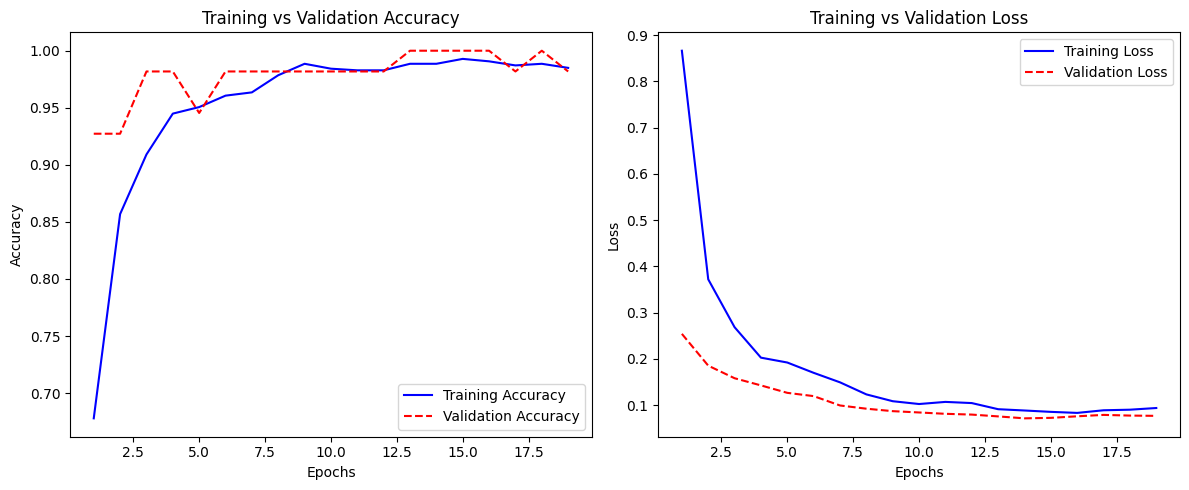

In [ ]:
import matplotlib.pyplot as plt

def plot_overfitting(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call this after training
plot_overfitting(history)


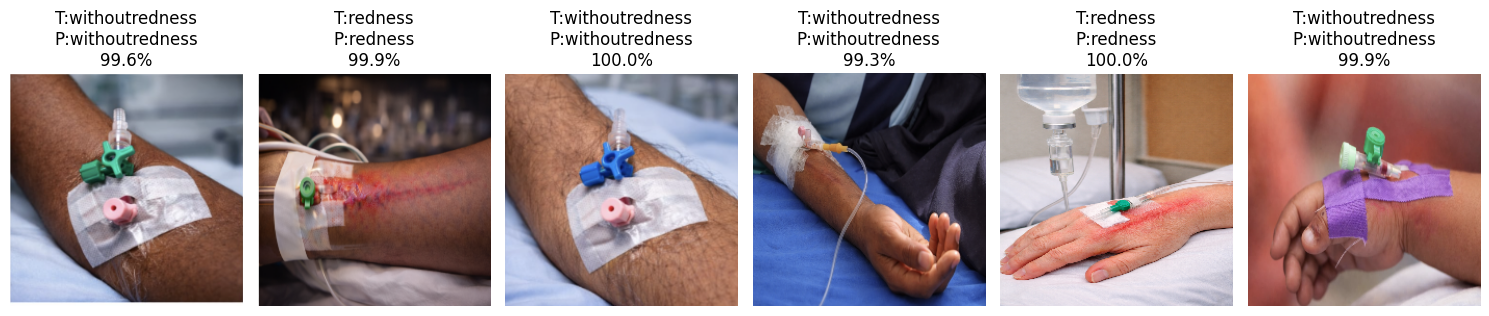

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ["withoutredness", "redness"]

idxs = np.random.choice(len(X_val_feat), 6, replace=False)

plt.figure(figsize=(15,5))

for i, idx in enumerate(idxs):

    pred = model.predict(
        X_val_feat[idx:idx+1],
        verbose=0
    )[0]

    pred_lbl = class_names[np.argmax(pred)]

    # FIX TRUE LABEL
    if len(y_val.shape) > 1:
        true_lbl = class_names[int(y_val[idx][0])]
    else:
        true_lbl = class_names[int(y_val[idx])]

    conf = np.max(pred) * 100

    plt.subplot(1,6,i+1)

    plt.imshow(X_val[idx].astype("uint8"))

    plt.title(
        f"T:{true_lbl}\n"
        f"P:{pred_lbl}\n"
        f"{conf:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

SWELLING